In [1]:
import matplotlib.pyplot as plt

#### Arch and GARCH

ARCH (Autoregressive Conditional Heteroskedasticity) and GARCH (Generalized ARCH) are time series models for **volatility**. Instead of assuming variance is constant over time, they model $\sigma_t^2$ as something that evolves based on past information.

The key empirical motivation is **volatility clustering** — large shocks tend to be followed by large shocks, and calm periods tend to persist. A constant $\sigma$ cannot capture this.





##### *"Autoregressive Conditionally Heteroskedastic Models"*

Variance today is a function of the past $q$ squared residuals. Only past shocks matter.


#### formula 1
$$y_t = \mu + \epsilon_t \quad \epsilon_t = \sigma_t z_t \quad z_t \sim i.i.d (0, 1)$$

$$
\begin{align*}
y_t &: \text{value observed at time } t \text{ (e.g. return at time } t\text{)} \\
\mu &: \text{constant mean of the process (e.g. mean return)} \\
\epsilon_t &: \text{shock (innovation, residual) at time } t \\
z_t &: \text{random variable distributed with mean 0 and variance 1}
\end{align*}
$$


#### formula 2 / variance:
$$\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2 + \alpha_2 \epsilon_{t-2}^2 + \ldots + \alpha_q \epsilon_{t-q}^2$$




$$\sigma_t^2 : \text{conditional variance at time } t$$

The volatility of $\epsilon_t$ given all past information. **"Conditional" means it is estimated based on how large the shocks in previous periods were.** The order $q$ determines how many lags are included.


$$\alpha_0 > 0$$

The constant term in the variance equation. It represents the baseline level of variance that persists even in the absence of any past shocks. Must be strictly positive to ensure $\sigma_t^2$ is never zero.


$$\alpha_i \geq 0 \quad \text{for } i = 1, 2, \ldots, q$$

The coefficient on the $i$-th lagged squared residual. It measures how strongly a shock from $i$ periods ago feeds into today's variance. Must be nonnegative to prevent $\sigma_t^2$ from turning negative.

$$\epsilon_{t-i}^2 : \text{squared residual (shock) from } i \text{ periods ago}$$

The squared value of the innovation at time $t-i$. Squaring removes the sign — direction of the shock does not matter, only its magnitude. Large past shocks produce large values of $\epsilon_{t-i}^2$, which in turn push $\sigma_t^2$ higher. This is the mechanism behind **volatility clustering**.


**Autoregressive :** Uses a linear combination of its own past values to estimate future states

**Heteroskedastic vs. Homoskedastic:** If a model is homoskedastic it proposes constant variance (volatility) which is not the case as observed in data! where if a model is heteroskedastic it propses variance (volatility) is not constant - more inline with what we observe in data!

**Conditionally Heteroskedastic:** Variance of errors in a model changes over time and is dependent on past information - quite useful here for volatility!

## ARCH(q)  How Many Lags?

The **q** in ARCH(q) controls how many periods back the model looks.

**ARCH(1):**
$$\sigma_t^2 = \alpha_0 + \alpha_1\epsilon_{t-1}^2$$
Only yesterday's shock matters. 1 parameter to estimate.

**ARCH(2):**
$$\sigma_t^2 = \alpha_0 + \alpha_1\epsilon_{t-1}^2 + \alpha_2\epsilon_{t-2}^2$$
Yesterday and the day before. 2 parameters.

**ARCH(50):**
$$\sigma_t^2 = \alpha_0 + \alpha_1\epsilon_{t-1}^2 + \alpha_2\epsilon_{t-2}^2 + \ldots + \alpha_{50}\epsilon_{t-50}^2$$
50 days back. 50 parameters to estimate.

**The problem with large q**

As q grows, the number of parameters grows with it. ARCH(50) requires estimating 50 separate $\alpha_i$ coefficients — statistically expensive and prone to overfitting. On top of that, every $\alpha_i \geq 0$ must hold, which becomes increasingly difficult to enforce as q increases.

**This is exactly why GARCH exists** — it carries the entire history of past variances through a single $\beta_1$ term, reducing an ARCH($\infty$) to just 3 parameters.
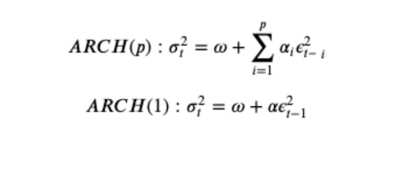

# GARCH(p,q) Models

$$\sigma_t^2 = \alpha_0 + \sum_{i=1}^{q} \alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2$$

Extends ARCH by also including past variances $\sigma_{t-j}^2$. The $\beta_j$ terms allow volatility to persist over time — a single large shock can keep variance elevated for many periods. In practice, **GARCH(1,1)** is the workhorse model:

$$\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

## ARCH(p) Models

$$\text{ARCH}(p): \quad \sigma_t^2 = \omega + \sum_{i=1}^{p} \alpha_i \epsilon_{t-i}^2$$

$$\text{ARCH}(1): \quad \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2$$



- $\sigma_t^2$: conditional variance at time $t$ (i.e., the squared volatility)
- $\omega$: constant term (represents a baseline level of variance), with $\omega > 0$
- $\alpha_i$: coefficient measuring the **impact of the shock (error) from $i$ periods ago on current variance**
- $\epsilon_{t-i}^2$: squared error (shock) at time $t-i$, i.e., the **lagged** "news" term
- $p$: number of lags included in the model
- In the special case of ARCH(1), only one lagged shock is used: $\alpha \epsilon_{t-1}^2$

**Intuition:** A large past shock ($\epsilon_{t-1}^2$ large) increases today's variance ($\sigma_t^2$), capturing **volatility clustering.**

### Conditional Variance
* Time varying variance, we calculate at point with out current information.
    * Remember **volatility clustering** and previous volatility/schok being correlated with current volatility.


## GARCH(p) Models
$$\text{GARCH}(p,q): \quad \sigma_t^2 = \omega + \sum_{i=1}^{p} \alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^{q} \beta_j \sigma_{t-j}^2$$

$$\text{GARCH}(1,1): \quad \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

**Where:**

- $\sigma_t^2$: conditional variance at time $t$
- $\omega$: constant term, with $\omega > 0$
- $\alpha_i$: coefficient on the $i$-th lagged squared shock (the "ARCH" part), capturing the effect of past news/shocks
- $\epsilon_{t-i}^2$: squared error (shock) at time $t-i$
- $\beta_j$: **coefficient on the $j$-th lagged conditional variance (the "GARCH" part), capturing volatility persistence**
- $\sigma_{t-j}^2$: conditional variance at time $t-j$
- $p$: number of ARCH lags (past shocks)
- $q$: number of GARCH lags (past variances)
- In GARCH(1,1), only one lag of each is used: $\alpha \epsilon_{t-1}^2$ and $\beta \sigma_{t-1}^2$

**Intuition:** GARCH extends ARCH by adding memory of **PAST VARIANCE** itself, not just past shocks. This makes volatility more persistent and smoother, since today's variance depends both on yesterday's shock ($\epsilon_{t-1}^2$) and yesterday's variance ($\sigma_{t-1}^2$).

**Key difference from ARCH:** ARCH only looks back at past squared errors, so it needs many lags ($p$) to capture long memory in volatility. GARCH achieves the same (or better) fit with far fewer parameters, because the $\beta \sigma_{t-1}^2$ term recursively carries information from all previous periods.

### GARCH(1,1) Parameter Constraints

To make the GARCH(1,1) process realistic, it requires:

- **Non-negativity constraint:** all parameters must be non-negative, so the variance cannot be negative.

$$\omega, \alpha, \beta \geq 0$$

- **Stationarity (mean-reversion) constraint:** model estimates must be "mean-reverting" toward the long-run variance.

$$\alpha + \beta < 1$$

**Long-run variance:**

$$\bar{\sigma}^2 = \frac{\omega}{1 - \alpha - \beta}$$

### Intuition

* The larger the $\alpha$, the bigger the immediate impact of the schock
* The larger the $beta$, the longer the impact of the schock
    * The closer $\alpha + \beta$ is to 1, the slower volatility reverts to its long-run average (high persistence). This is often what's observed empirically in financial markets, values are typically close to 1 (e.g., 0.95–0.99).



# Using GARCH-Model (Mean Equation)

The formulas described on top are for modelling the VARIANCE $\sigma_t^2 % , and the variance itself used in mean equation.


- **r_t = μ + ε_t** → *(realized return at time t = mean return + shock at time t)*

$$r_t = \mu + \epsilon_t$$

- **ε_t = σ_t · z_t** → *(shock at time t = volatility at time t × standardized random component)*

$$\epsilon_t = \sigma_t \cdot z_t$$

- **σ²_t** → *(conditional variance of the shock ε_t, modeled by the GARCH equation)*

$$\sigma_t^2 = E[\epsilon_t^2 \mid \mathcal{F}_{t-1}]$$





## Standartized Residuals

Residual = predicted return minus mean return:

$$\epsilon_t = r_t - \mu_t$$

Standardized residual = residual divided by the model's estimated volatility:

$$\text{stdResid} = \frac{\epsilon_t}{\sigma_t} = z_t$$

Residual (ϵt) is the part the model couldn't predict. A model like GARCH estimates μt, [**and when you subtract it from the realized return rt, what's left is the "shock.**]     (equation nr1)"

The point of standardizing is to remove volatility clustering. On calm days the market produces small ϵt, on turbulent days large ones, so comparing raw residuals across time is misleading. **Dividing by σt normalizes each shock to "how many units large relative to that period's own volatility."**

# 3 Model Assumptions needs to be set:

Model Specification
Three assumptions to set:

### Distribution of residuals:
"normal" (default), "t" (Student's t), "skewt" (skewed Student's t)

* This defines the shape of the standardized residuals' distribution, which matters for both estimation and quantile-based calculations (like VaR).

* **"normal" (default):** Assumes residuals follow a standard normal distribution. Simple, but financial returns often have fatter tails (more extreme events) than a normal distribution predicts.

* **"t" (Student's t):** Has fatter tails than normal, controlled by a degrees-of-freedom parameter $\nu$
    * Lower $\nu$= fatter tails = more weight on extreme events. Often fits financial data better than normal.
* **skewt" (skewed Student's t):** Like "t", but also allows asymmetry (skewness), since financial returns often have a longer/fatter left tail (crashes) than right tail (rallies).


### Mean model:
"constant" (default), "zero", "AR"

* this defines how the conditional mean $\mu_t$ (the expected return) is modeled.

* **"constant" (default):** Assumes a single, fixed mean across the whole series. **Works well for most liquid financial asset returns**, since their average return doesn't vary much day-to-day.

* **"zero":** Assumes $\mu_t =0$. Useful when the mean has already been modeled separately by another process (e.g., an AR, MA, or ARMA model), and you're feeding those residuals into GARCH purely to estimate volatility.

* **"AR" (autoregressive):** Models the current mean as correlated with past values (lags) of the series. You specify the mean model as "AR" along with the number of lags. Useful when returns show serial correlation, though this is less common for daily returns and more relevant for other financial time series.


### Volatility model:
"GARCH" (default), "ARCH", "EGARCH"

* **"GARCH" (default):** The standard model, $\sigma_t^2$
depends on past squared shocks (ARCH term) and past variance (GARCH term). Assumes symmetric effects, positive and negative shocks impact volatility equally.

* **"ARCH":** The simpler predecessor to GARCH, $\sigma_t^2$
depends only on past squared shocks (no memory of past variance). Needs many lags to capture the same persistence GARCH achieves with just one.

* **"EGARCH" (exponential GARCH):** Models the log of variance instead of variance itself, and adds a conditional term to capture **asymmetric shocks (the leverage effect, where negative shocks increase volatility more than positive ones)**. Because it's based on log-variance, it doesn't require non-negativity constraints on parameters, making it computationally faster to fit.


# Preimplemented GARCH Model with arch package



In [3]:
import pandas as pd
import numpy as np

In [4]:

tickers = ["AAPL", "JPM", "XOM", "KO"]

close_price = pd.read_csv("../data_general/4_ticker_data.csv")

close_price["Date"] = pd.to_datetime(close_price["Date"])
close_price = close_price.set_index("Date").sort_index()

percent_return = close_price.pct_change()

In [5]:
from arch import arch_model

In [6]:
percent_return_scaled = percent_return * 100 # optimizer warned us that values in decimal form 0.002 might result in gradient saturation

basic_gm = arch_model(percent_return_scaled["AAPL"].dropna(), p=1,q=1,mean='constant', vol='garch', dist='normal')

In [7]:
gm_result = basic_gm.fit(update_freq=4)

Iteration:      4,   Func. Count:     31,   Neg. LLF: 5618.493180690575
Iteration:      8,   Func. Count:     53,   Neg. LLF: 2508.6231936246204
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2508.6231936246204
            Iterations: 9
            Function evaluations: 57
            Gradient evaluations: 9


In [8]:
gm_result.params

mu          0.158021
omega       0.101511
alpha[1]    0.083571
beta[1]     0.889009
Name: params, dtype: float64

- **μ (Mean, 0.1580):** The estimated unconditional mean of daily returns is approximately 0.158% (percent-scale).

- **ω (Omega, 0.1015):** The constant term in the conditional variance equation. This anchors the baseline level of variance in conjunction with the ARCH and GARCH coefficients.

- **α₁ (ARCH term, 0.0836):** Measures the sensitivity of current conditional variance to the previous period's squared residual (shock). A value of 0.0836 indicates a moderate but non-trivial reaction to recent return surprises.

- **β₁ (GARCH term, 0.8890):** Captures the persistence of past conditional variance. A value of 0.8890 indicates that volatility shocks decay slowly, i.e., the variance process exhibits strong memory.

- **Persistence (α₁ + β₁ = 0.9726):**
  - Close to unity, indicating high volatility persistence, consistent with stylized facts of daily equity return data (volatility clustering).
  - Below 1, confirming covariance stationarity, i.e., the unconditional variance is finite and the process is mean-reverting, albeit slowly.


In [9]:
gm_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2508.62
Distribution:                  Normal   AIC:                           5025.25
Method:            Maximum Likelihood   BIC:                           5045.79
                                        No. Observations:                 1257
Date:                Wed, Jul 08 2026   Df Residuals:                     1256
Time:                        00:06:08   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1580  5.124e-02      3.084  2.044e-03 [5.759e-02,  0.258]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1015  7.302e-02      1.390      0.165 [-4.161e-02,  0.245]
alpha[1]       0.0836  3.244e-02      2.576  9.999e-03  [1.998e-02,  0.147]
beta[1]        0.8890  4.765e-02     18.657  1.114e-77    [  0.796,  0.982]
===========================================================================

Covariance estimator: robust
"""

# Forecasting with GARCH


## Return Forecast

A GARCH model decomposes the return as:

$$
r_{t+1} = \mu_{t+1|t} + \sigma_{t+1|t} \cdot z_{t+1}
$$

where:

- $\mu_{t+1|t}$ : conditional mean forecast (given information up to time $t$)
- $\sigma_{t+1|t}$ : conditional volatility forecast
- $z_{t+1}$ : standardized (white noise) innovation, $z_{t+1} \sim D(0,1)$ — zero mean, unit variance
  (Normal, Student-t, skewed-t, etc.)



## Variance Forecast

For t+1 =
$$\sigma_{t+1}^2 = \omega + \alpha \epsilon_t^2 + \beta \sigma_t^2$$

Both ε²_t and σ²_t correspond to realized, observed quantities at time.



Fort t>1 =

$$\sigma_{t+h}^2 = \omega + (\alpha + \beta)\, \sigma_{t+h-1}^2$$

For horizons beyond one period, the realized shock ε_(t+h-1) is not yet observed. The unknown squared shock term is replaced by **the model's own variance forecast from the preceding period.**






In [10]:
close_price.tail(4)


,AAPL,JPM,KO,XOM
Date,,,,
2024-12-26,257.612732,235.823593,60.361835,102.039902
2024-12-27,254.201370,233.912888,60.246071,102.030319
2024-12-30,250.829773,232.118561,59.840893,101.340408
2024-12-31,249.059464,232.496826,60.062771,103.074760


In [11]:

gm_forecast = gm_result.forecast(horizon = 5)
gm_forecast.mean

,h.1,h.2,h.3,h.4,h.5
Date,,,,,
2024-12-31,0.158021,0.158021,0.158021,0.158021,0.158021


Since   `mean='constant' is selected`, the model returns the same value for every horizon: **μ = 0.158021**. This is because in a constant mean model, the expected future return is always the same fixed mean, it doesn't vary over time.


In [12]:
gm_forecast.variance

,h.1,h.2,h.3,h.4,h.5
Date,,,,,
2024-12-31,1.801907,1.854008,1.904681,1.953964,2.001895


gYour forecasts increasing gradually, **1.801907 → 1.854008 → 1.904681 → 1.953964 → 2.001895**, is exactly the expected behavior, because:

- The **long-run (unconditional) variance**, given the parameters, is:

$$\bar{\sigma}^2 = \frac{\omega}{1-\alpha-\beta} = \frac{0.1015}{1-0.9726} \approx 3.70$$

- The current conditional variance (1.80 at h=1) sits below this long-run mean (≈3.70), meaning the market is currently in a relatively "calm" volatility regime.

- Since α+β = 0.9726 is very high (high persistence), the variance forecast converges to the long-run mean **very slowly**, with only a small increase at each step (≈0.05 per step).


Date,2024-12-31
h.001,1.801907
h.002,1.854008
h.003,1.904681
h.004,1.953964
h.005,2.001895
...,...
h.176,3.687334
h.177,3.687736
h.178,3.688126
h.179,3.688506


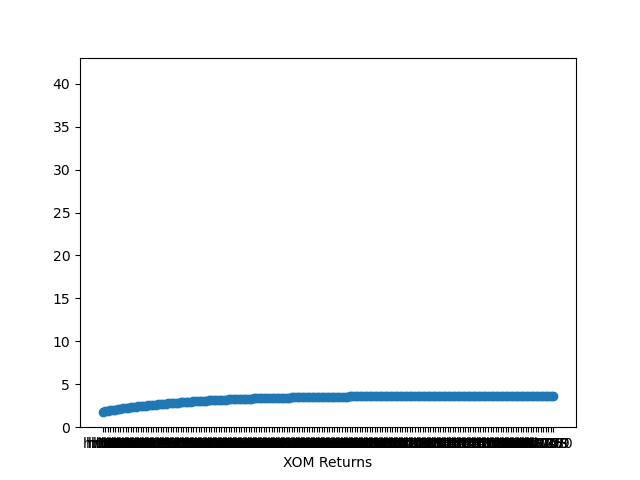

In [13]:
gm_forecast = gm_result.forecast(horizon = 180)

thundert_day_data = gm_forecast.variance.transpose()

display(thundert_day_data)

plt.scatter(thundert_day_data.index, thundert_day_data['2024-12-31'])
plt.yscale('linear')
plt.show()


## Expanding Window Forecast

In [14]:
percent_return_scaled = percent_return * 100

period_of_forecast = 252
forecasts = {}

weekday_indexes = percent_return_scaled.sort_index(ascending=False).index


for target_date in weekday_indexes[:period_of_forecast]:
    returns_with_cutoff_date = percent_return_scaled.loc[:target_date]

    basic_gm = arch_model(
        returns_with_cutoff_date["AAPL"].dropna(),
        p=1,
        q=1,
        mean="constant",
        vol="garch",
        dist="normal"
    )

    res = basic_gm.fit(disp="off")

    forecast_data = res.forecast(horizon=1)
    forecast_value = forecast_data.variance.loc[target_date, "h.1"]

    forecast_index = target_date + pd.Timedelta(days=1)
    forecasts[forecast_index] = forecast_value

variance_forecasts_expanding = pd.DataFrame.from_dict(
    forecasts,
    orient="index",
    columns=["variance_forecast"]
).sort_index()


In [15]:
variance_forecasts_expanding

,variance_forecast
2024-01-03,2.771450
2024-01-04,2.603221
2024-01-05,2.595428
2024-01-06,2.399699
2024-01-09,2.740433
...,...
2024-12-25,1.745642
2024-12-27,1.647726
2024-12-28,1.754280
2024-12-31,1.848063


## Rolling Window Forecast





In [16]:
`
percent_return_scaled = percent_return * 100

period_of_forecast = 252
window_size = 20

forecasts = {}

for target_date in weekday_indexes[:period_of_forecast]:

    #only difference is here:
    start_date = target_date - pd.Timedelta(days=window_size)

    returns_with_cutoff_date = percent_return_scaled.loc[start_date:target_date]

    basic_gm = arch_model(
        returns_with_cutoff_date["AAPL"].dropna(),
        p=1,
        q=1,
        mean="constant",
        vol="garch",
        dist="normal"
    )

    res = basic_gm.fit(disp="off")

    forecast_data = res.forecast(horizon=1)
    forecast_value = forecast_data.variance.loc[target_date, "h.1"]

    forecast_index = target_date + pd.Timedelta(days=1)
    forecasts[forecast_index] = forecast_value

variance_forecasts_rolling = pd.DataFrame.from_dict(
    forecasts,
    orient="index",
    columns=["variance_forecast"]
).sort_index()



In [17]:
variance_forecasts_rolling

,variance_forecast
2024-01-03,1.299062
2024-01-04,1.439522
2024-01-05,1.401357
2024-01-06,1.297787
2024-01-09,2.394838
...,...
2024-12-25,1.217403
2024-12-27,1.040143
2024-12-28,1.365683
2024-12-31,1.570611


In [18]:
import plotly.graph_objects as go

diff = variance_forecasts_rolling['variance_forecast'] - variance_forecasts_expanding['variance_forecast']

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=diff.index,
    y=diff.values,
    mode='lines',
    line=dict(color='#c96a6a', width=1.5),
    name='rolling - expanding'
))

fig.update_layout(
    xaxis_title='index',
    yaxis_title='variance_forecast (difference)',
    template='plotly_white',
    xaxis=dict(tickangle=-90, showgrid=True),
    yaxis=dict(showgrid=True),
    height=550
)

fig.show()

# Computing VaR with GARCH-Results

## Calculating Empirical Var Using Residiuals

* Using directly quantile function on calculated residuals, as if done on returns, **IS ENOUGH to calculate VaR*

* The quantile of the residuals tells you, in "standardized-world" terms, how bad the loss is (in units of sigma). Multiplying by $\sigma$ and adding $\mu$ then carries that back into the "real world," i.e. the actual return scale.

* Empirical method is also easier to use to calculate **CVAR.**

Why:

#### Core idea: quantiles are preserved under linear transformation

Suppose you have a random variable $z$ and you pass it through a linear
transformation:

$$
r = \mu + \sigma \cdot z
$$

where $\mu$ and $\sigma$ are constants (or known at time $t$), with $\sigma > 0$.

**Key mathematical fact:** If $q$ is the $\alpha$-quantile of $z$'s distribution
(i.e. $P(z \le q) = \alpha$), then $\mu + \sigma q$ is automatically the
$\alpha$-quantile of $r$.

#### Rescaling:

$$ \text{VaR}_\alpha = \mu + \sigma \cdot q_\alpha $$
this quantile transformation will express the VaR at return terms.


## Mathematical Definition of (Parametric) VaR with Variance

VaR is defined as the α-quantile of the return distribution: the value such that the
probability of the return falling below it is exactly α.

$$
P(r_{t+1} \le \text{VaR}_{\alpha,t+1}) = \alpha
$$

Equivalently, in terms of the inverse CDF of the return distribution:

$$
\text{VaR}_{\alpha,t+1} = F_r^{-1}(\alpha)
$$

## Intuitive summary:
* You want to find the quantile of the return, but the return is a raw, non-standardized random variable.
* So you convert it into standardized form (z), **find the quantile of z (standartized residuals(**, then "un-standardize" it back using the mean and volatility.
    * This is exactly the same $x \mu + \sigma z$ transformation you use to get a quantile out of any $\text{Normal}(\mu, \sigma^2)$  distribution, just carried over to the GARCH setting. The only difference is that here μ and σ are time-varying (conditional/dynamic) instead of fixed constants.


remembering how GARCH defined the returns:

$$
r_{t+1} = \mu_{t+1|t} + \sigma_{t+1|t} \cdot z_{t+1}
$$

subsituting that into the VaR definition:

$$
P(r_{t+1} \le \text{VaR}_\alpha) = \alpha
$$

$$
P(\mu_{t+1|t} + \sigma_{t+1|t} \cdot z_{t+1} \le \text{VaR}_\alpha) = \alpha
$$

Since $\sigma_{t+1|t} > 0$, dividing preserves the inequality direction:

$$
P\left(z_{t+1} \le \frac{\text{VaR}_\alpha - \mu_{t+1|t}}{\sigma_{t+1|t}}\right) = \alpha
$$

The left-hand side is the CDF of $z$ evaluated at that point:

$$
F_z\left(\frac{\text{VaR}_\alpha - \mu_{t+1|t}}{\sigma_{t+1|t}}\right) = \alpha
$$

Apply $F_z^{-1}$ to both sides:

$$
\frac{\text{VaR}_\alpha - \mu_{t+1|t}}{\sigma_{t+1|t}} = F_z^{-1}(\alpha) \equiv q_\alpha
$$

## Here $q_\alpha$ is exactly the α-quantile of the standardized residual distribution
* (what `ppf(0.05)` or `std_resid.quantile(0.05)` computes).
*
Rearranging for $\text{VaR}_\alpha$:

$$
\boxed{\text{VaR}_{\alpha,t+1} = \mu_{t+1|t} + \sigma_{t+1|t} \cdot q_\alpha}
$$


## Calculating Parametric VaR

In [26]:
x = basic_gm.distribution #recieving distrubution of standartized residuals
print(type(x))

five_percent_quantile= x.ppf(0.05)
five_percent_quantile


<class 'arch.univariate.distribution.Normal'>


np.float64(-1.6448536269514729)

Here garch fitted nothing, as we have choosen in model description the normal distrubution.

`basic_gm = arch_model(percent_return_scaled["AAPL"].dropna(), p=1,q=1,mean='constant', vol='garch', dist='normal')`

In case student t or skewed t had choosen, according to our degres of freedom (nu $\nu$) and skewness parameter, it would fix and give us an fitted normal distrubution.


In [29]:
mean_forecast = gm_forecast.mean
variance_forecast = gm_forecast.variance

VaR_parametric_scaled = mean_forecast.values + np.sqrt(variance_forecast).values * five_percent_quantile
VaR_parametric_scaled



array([[-2.04994988, -2.08164354, -2.11204373, -2.1412248 , -2.16925474,
        -2.19619598, -2.22210597, -2.24703774, -2.27104042, -2.29415956,
        -2.31643758, -2.33791397, -2.35862568, -2.37860724, -2.39789105,
        -2.41650754, -2.43448532, -2.45185136, -2.46863107, -2.48484848,
        -2.5005263 , -2.51568605, -2.5303481 , -2.54453181, -2.55825555,
        -2.57153679, -2.58439215, -2.59683747, -2.60888783, -2.62055763,
        -2.63186061, -2.64280991, -2.65341806, -2.66369708, -2.67365845,
        -2.68331317, -2.69267178, -2.7017444 , -2.71054072, -2.71907004,
        -2.72734129, -2.73536306, -2.7431436 , -2.75069082, -2.75801235,
        -2.76511553, -2.77200742, -2.77869482, -2.78518427, -2.79148207,
        -2.79759432, -2.80352686, -2.80928535, -2.81487524, -2.82030179,
        -2.82557007, -2.83068498, -2.83565126, -2.84047347, -2.84515602,
        -2.84970318, -2.85411907, -2.85840767, -2.86257284, -2.86661829,
        -2.87054763, -2.87436434, -2.87807179, -2.8

Values here are scaled with 100, thereby **at first glance it looks like we have recieved an VAR of -2,04 meaning %-204.

And as we are in return universe not the loss, the output values are negative but that doesnt mean a pozitive loss.



In [31]:
VaR_parametric = VaR_parametric_scaled / 100 * -1

VaR_parametric

array([[0.0204995 , 0.02081644, 0.02112044, 0.02141225, 0.02169255,
        0.02196196, 0.02222106, 0.02247038, 0.0227104 , 0.0229416 ,
        0.02316438, 0.02337914, 0.02358626, 0.02378607, 0.02397891,
        0.02416508, 0.02434485, 0.02451851, 0.02468631, 0.02484848,
        0.02500526, 0.02515686, 0.02530348, 0.02544532, 0.02558256,
        0.02571537, 0.02584392, 0.02596837, 0.02608888, 0.02620558,
        0.02631861, 0.0264281 , 0.02653418, 0.02663697, 0.02673658,
        0.02683313, 0.02692672, 0.02701744, 0.02710541, 0.0271907 ,
        0.02727341, 0.02735363, 0.02743144, 0.02750691, 0.02758012,
        0.02765116, 0.02772007, 0.02778695, 0.02785184, 0.02791482,
        0.02797594, 0.02803527, 0.02809285, 0.02814875, 0.02820302,
        0.0282557 , 0.02830685, 0.02835651, 0.02840473, 0.02845156,
        0.02849703, 0.02854119, 0.02858408, 0.02862573, 0.02866618,
        0.02870548, 0.02874364, 0.02878072, 0.02881673, 0.02885172,
        0.02888571, 0.02891873, 0.02895081, 0.02

Thereby, we've recieved for the stock apple  an GARCH based VaR estimation for an horizotn of 180 days.

Historical VaR at the 95% confidence level was 3.01%, and the historical CVaR is 4.44%.
Our model assumed an Var of %2.04


## Calculating Empirical VaR and CVar




In [40]:
#standart residuals for each day:
std_resid = gm_result.std_resid



std_resid

Date
2020-01-03   -0.477184
2020-01-06    0.280247
2020-01-07   -0.288158
2020-01-08    0.694619
2020-01-09    0.964546
                ...   
2024-12-24    0.748358
2024-12-26    0.121008
2024-12-27   -1.154202
2024-12-30   -1.121670
2024-12-31   -0.636364
Name: std_resid, Length: 1257, dtype: float64

In [41]:
# 5percent quantile:

quantile_5percent = std_resid.quantile(0.05)
quantile_5percent

np.float64(-1.657107456967116)

In [42]:
# transforming this quantile value to return terms
mean_forecast = gm_forecast.mean
variance_forecast = gm_forecast.variance

VaR_empirical = mean_forecast.values + np.sqrt(variance_forecast).values * quantile_5percent

VaR_empirical



array([[-2.06639882, -2.0983286 , -2.12895526, -2.15835372, -2.18659248,
        -2.21373443, -2.23983744, -2.26495495, -2.28913644, -2.31242782,
        -2.3348718 , -2.35650819, -2.3773742 , -2.39750461, -2.41693209,
        -2.43568727, -2.45379898, -2.47129439, -2.4881991 , -2.50453733,
        -2.52033195, -2.53560463, -2.55037592, -2.56466529, -2.57849127,
        -2.59187145, -2.60482258, -2.61736061, -2.62950075, -2.64125749,
        -2.65264468, -2.66367554, -2.67436272, -2.68471832, -2.69475389,
        -2.70448054, -2.71390888, -2.72304909, -2.73191093, -2.74050379,
        -2.74883667, -2.7569182 , -2.76475669, -2.77236014, -2.77973622,
        -2.78689232, -2.79383555, -2.80057277, -2.80711056, -2.81345528,
        -2.81961306, -2.8255898 , -2.83139119, -2.83702273, -2.8424897 ,
        -2.84779723, -2.85295025, -2.85795352, -2.86281165, -2.86752909,
        -2.87211012, -2.87655891, -2.88087946, -2.88507566, -2.88915125,
        -2.89310986, -2.896955  , -2.90069008, -2.9

In [43]:
#erasing effects of scaling done in previous steps
VaR_empirical = VaR_empirical / 100
VaR_empirical

array([[-0.02066399, -0.02098329, -0.02128955, -0.02158354, -0.02186592,
        -0.02213734, -0.02239837, -0.02264955, -0.02289136, -0.02312428,
        -0.02334872, -0.02356508, -0.02377374, -0.02397505, -0.02416932,
        -0.02435687, -0.02453799, -0.02471294, -0.02488199, -0.02504537,
        -0.02520332, -0.02535605, -0.02550376, -0.02564665, -0.02578491,
        -0.02591871, -0.02604823, -0.02617361, -0.02629501, -0.02641257,
        -0.02652645, -0.02663676, -0.02674363, -0.02684718, -0.02694754,
        -0.02704481, -0.02713909, -0.02723049, -0.02731911, -0.02740504,
        -0.02748837, -0.02756918, -0.02764757, -0.0277236 , -0.02779736,
        -0.02786892, -0.02793836, -0.02800573, -0.02807111, -0.02813455,
        -0.02819613, -0.0282559 , -0.02831391, -0.02837023, -0.0284249 ,
        -0.02847797, -0.0285295 , -0.02857954, -0.02862812, -0.02867529,
        -0.0287211 , -0.02876559, -0.02880879, -0.02885076, -0.02889151,
        -0.0289311 , -0.02896955, -0.0290069 , -0.0

### Calculating Empirical CVar

In [44]:
tail_mean_empirical = std_resid[std_resid <= quantile_5percent].mean()

CVaR_empirical = mean_forecast.values + np.sqrt(variance_forecast).values * tail_mean_empirical

CVaR_empirical

array([[-2.8523812 , -2.89559313, -2.9370415 , -2.97682768, -3.0150444 ,
        -3.05177675, -3.08710307, -3.12109567, -3.15382151, -3.18534272,
        -3.21571711, -3.24499856, -3.27323741, -3.30048077, -3.3267728 ,
        -3.35215498, -3.37666633, -3.40034361, -3.42322148, -3.4453327 ,
        -3.46670823, -3.4873774 , -3.50736801, -3.52670643, -3.54541772,
        -3.56352568, -3.581053  , -3.59802125, -3.61445101, -3.63036191,
        -3.64577268, -3.66070121, -3.67516463, -3.6891793 , -3.70276087,
        -3.71592436, -3.72868413, -3.74105396, -3.75304708, -3.76467616,
        -3.77595339, -3.78689047, -3.79749864, -3.80778871, -3.81777107,
        -3.82745572, -3.8368523 , -3.84597006, -3.85481793, -3.86340452,
        -3.8717381 , -3.87982668, -3.88767795, -3.89529934, -3.90269803,
        -3.90988093, -3.91685473, -3.92362588, -3.93020059, -3.9365849 ,
        -3.94278461, -3.94880534, -3.95465253, -3.96033142, -3.96584709,
        -3.97120445, -3.97640824, -3.98146307, -3.9

In [45]:
# erasing effects of scaling done in previous steps
CVaR_empirical = CVaR_empirical / 100
CVaR_empirical

array([[-0.02852381, -0.02895593, -0.02937041, -0.02976828, -0.03015044,
        -0.03051777, -0.03087103, -0.03121096, -0.03153822, -0.03185343,
        -0.03215717, -0.03244999, -0.03273237, -0.03300481, -0.03326773,
        -0.03352155, -0.03376666, -0.03400344, -0.03423221, -0.03445333,
        -0.03466708, -0.03487377, -0.03507368, -0.03526706, -0.03545418,
        -0.03563526, -0.03581053, -0.03598021, -0.03614451, -0.03630362,
        -0.03645773, -0.03660701, -0.03675165, -0.03689179, -0.03702761,
        -0.03715924, -0.03728684, -0.03741054, -0.03753047, -0.03764676,
        -0.03775953, -0.0378689 , -0.03797499, -0.03807789, -0.03817771,
        -0.03827456, -0.03836852, -0.0384597 , -0.03854818, -0.03863405,
        -0.03871738, -0.03879827, -0.03887678, -0.03895299, -0.03902698,
        -0.03909881, -0.03916855, -0.03923626, -0.03930201, -0.03936585,
        -0.03942785, -0.03948805, -0.03954653, -0.03960331, -0.03965847,
        -0.03971204, -0.03976408, -0.03981463, -0.0